In [1]:
import os # For finding files
import numpy as np # For math and array calculations
import matplotlib.pyplot as plt # For drawing the EDA histogram
from PIL import Image, ImageFilter # For opening images and applying edge detection

In [2]:
base_dir = r'C:\Users\vinuga janandith\Desktop\AIML project\data'
edge_densities = []

print("Extracting texture features (Edge Detection) for ALL images...")

# Loop through all files
for root, dirs, files in os.walk(base_dir):
    if not dirs: 
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                file_path = os.path.join(root, file)
                try:
                    # Open the image and convert it to Grayscale ('L')
                    with Image.open(file_path).convert('L') as img:
                        
                        # DATA PREPROCESSING: Feature Engineering
                        # Apply an edge finding filter to highlight cracks and potholes
                        edges = img.filter(ImageFilter.FIND_EDGES)
                        
                        # Calculate the average edge intensity (texture complexity)
                        edge_array = np.array(edges) 
                        mean_edge = np.mean(edge_array)
                        edge_densities.append(mean_edge)
                except Exception:
                    pass

print(f"Successfully extracted features from {len(edge_densities)} images.")

Extracting texture features (Edge Detection) for ALL images...
Successfully extracted features from 9660 images.


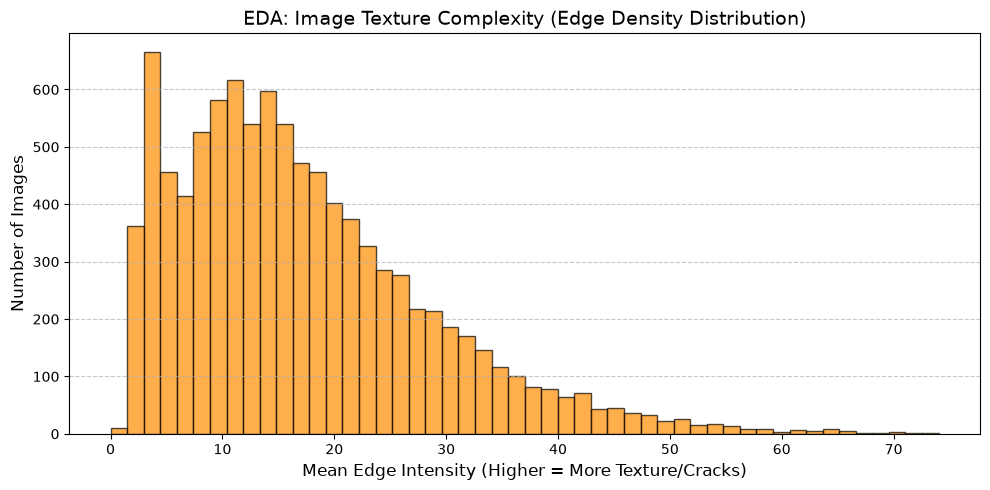

In [3]:
# EXPLORATORY DATA ANALYSIS (EDA)
# Plot a Histogram of the texture complexity
plt.figure(figsize=(10, 5))
plt.hist(edge_densities, bins=50, color='darkorange', edgecolor='black', alpha=0.7)

plt.title('EDA: Image Texture Complexity (Edge Density Distribution)', fontsize=14)
plt.xlabel('Mean Edge Intensity (Higher = More Texture/Cracks)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()